In [1]:
import os
import os.path
import fnmatch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from itertools import chain
from scipy.fftpack import fft, ifft

In [2]:
# Assess similarity across neuronal activity patterns
def Cosine_similarity (number, drink, behavior, savecsv):
    
    """
    number: NO. of mouse
    drink: drink
    behavior: behavior
    savecsv: save path
    
    """
    
    # Read csv file
    fdir1 = "./Calcium_imaging_data/" + drink + "/" + number + "/"+ behavior
    z_score_activity = pd.read_csv(fdir1+ "/output_files/accrawt_z.csv", index_col=0, header=0).values

    # Generate cosine similarity of shuffled social interaction and calcium signal
    np.random.seed(17)
    shuffletimes = 10000   #shuffled 10000times

    cs_cell_all = []
    cs_p_all = []
    
    for i in np.arange(len(z_score_activity)):
        cs_cell = []
        cs_p_cell = []

        for j in np.arange(len(z_score_activity)):
            cs_raw_ind = []
            cs_shuffle_ind = []
            cs_p1 = 0
            
            if i >= j:
                rowr1 = z_score_activity[i,:]
                rowr2= z_score_activity[j,:]

                #Cosine  similarity (Raw data)
                cs_raw = cosine_similarity([rowr1], [rowr2]).tolist()
                cs_raw2 = list(chain(*cs_raw))

                for a in tqdm(range (shuffletimes)):

                    # Fourier transformation
                    trace_fft = fft(rowr2)    #FFT
                    amp = np.abs(trace_fft)    #Amplitude
                    phase = np.angle(trace_fft)    #Phase
        #             sample_rate = 10
        #             freq = np.fft.fftfreq(z_score_activity.size, d = 1 / sample_rate)      #Frequency

                    # Phase randomization
                    ph_noise = np.random.permutation(phase)
        #             trace_random = ifft(amp * np.exp(1j * ph_noise))
                    trace_random =  np.round(np.abs(ifft(amp * np.exp(1j*ph_noise))))    #https://github.com/JackEdTaylor/randphase

                    # Cosine similarity (Shuffled data)
                    cs_shuffle = cosine_similarity([rowr1], [trace_random]).tolist()
                    cs_shuffle2 = list(chain(*cs_shuffle))

                    for k in cs_shuffle2:
                        cs_shuffle_ind.append(k)

                        if k >= cs_raw2[0]:
                            cs_p1 += 1

                cs_p =  cs_p1/shuffletimes
                cs_p_cell.append(cs_p)

                cs_cell.append(cs_raw2[0])
                
            else:
                cs_p_cell.append(np.nan)
                cs_cell.append(np.nan)

        cs_cell_all.append(cs_cell)
        cs_p_all.append(cs_p_cell)
        
    #save as CSV files
    pd.DataFrame(cs_cell_all).to_csv(savecsv + "cosine_similarity.csv")

    #save as CSV files
    pd.DataFrame(cs_p_all).to_csv(savecsv + "cosine_similarity_p.csv")

In [5]:
# Evaluate neuronal centrality

def Networkx_function_OE (nm, dk, bh, savecsv, savefig):    
    
    """
    nm: NO. of mouse
    dk: drink
    bh: behavior
    savecsv: save path (csv file)
    savefig: save path (figure)
    
    """
    
    # Read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt", index_col=0)
    #read Multi-session registration file
    MSR = pd.read_csv("./Calcium_imaging_data/Multi-session_registration_"+ nm +".csv", index_col=0, header=0)


    # Read Cosine similarity and P_value files
    CS_table = pd.read_csv(savecsv + "cosine_similarity.csv", index_col=0)
    CS_table.index = CS_table.index+1
    CS_table.columns = CS_table.index

    CS_p_table = pd.read_csv(savecsv + "cosine_similarity_p.csv", index_col=0)
    CS_p_table.index = CS_p_table.index+1
    CS_p_table.columns = CS_p_table.index


    # Plot heatmap and networks
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    sns.heatmap(CS_table)
    plt.title("Cosine Similarity")

    plt.subplot(1,3,2)
    sns.heatmap(CS_p_table, cmap="Greys")
    plt.title("Cosine Similarity_p")

    plt.subplot(1,3,3)
    G = nx.Graph()
    colors = []
    cell_type = []

    if dk =="Water":
        col = "Water_OE"
        
    elif dk =="Cocktail":
        col = "Cocktail_OE"
    
    for i in CS_table.index:
        G.add_node(i)

        # Define color
        for k in range(len(MSR)):
            if MSR.loc[k][dk + "_" + bh] == i:

                if Parsing_cells.loc[k][col] == "activation":
                    colors.append("red")
                    cell_type.append("activation")
                elif Parsing_cells.loc[k][col] == "inhibition":
                    colors.append("lightblue")
                    cell_type.append("inhibition")
                else:
                    colors.append("gray")
                    cell_type.append("other")

        for j in CS_table.columns:
            if i != j:
                if CS_p_table.loc[i][j] <= 0.0083:
                    w = CS_table.loc[i][j]
                    G.add_edge(i,j, weight= w)
        #             G.add_edge(i,j, weight= round(w,1))

    pos = nx.spring_layout(G, scale=1, seed=17)
    # weight= nx.get_edge_attributes(G, "weight")

    nx.draw_networkx(G, pos, with_labels=True, font_weight='bold', 
                     node_size=40, font_size=5, alpha=1, node_color=colors,
                     edge_color='orange')
    plt.title("Networks")
    plt.box(False)
    
    plt.tight_layout()

#     plt.savefig(savefig + "Networkx.pdf", transparent=True, bbox_inches="tight")
    
    
    # Degree_centrality
    DC = pd.DataFrame.from_dict(nx.degree_centrality(G), orient='index', columns=["Degree_centrality"])
    # Eigenvector_centrality
    EC = pd.DataFrame.from_dict(nx.eigenvector_centrality(G, max_iter=1000), orient='index', columns=["Eigenvector_centrality"])
    All_centrality = pd.concat([DC,EC], axis=1)
    All_centrality["Cell_type"] = cell_type
    
    # Save as CSV files
    pd.DataFrame(All_centrality).to_csv(savecsv + "Centrality_all.csv")
    
    G.clear()

In [14]:
# Plot network of OE neurons

def Networkx_fig_OE (nm, dk, bh, savecsv, savefig):    
    # Read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt", index_col=0)
    # Read Multi-session registration file
    MSR = pd.read_csv("./Calcium_imaging_data/Multi-session_registration_"+ nm +".csv", index_col=0, header=0)


    #read Cosine similarity and P_value files
    CS_table = pd.read_csv(savecsv + "cosine_similarity.csv", index_col=0)
    CS_table.index = CS_table.index+1
    CS_table.columns = CS_table.index

    CS_p_table = pd.read_csv(savecsv + "cosine_similarity_p.csv", index_col=0)
    CS_p_table.index = CS_p_table.index+1
    CS_p_table.columns = CS_p_table.index


    # Plot networks
    plt.figure(figsize=(4,4))

    G = nx.Graph()
    colors = []
    cell_type = []

    if dk =="Water":
        col = "Water_OE"
        
    elif dk =="Cocktail":
        col = "Cocktail_OE"
    
    for i in CS_table.index:
        G.add_node(i)

        # Define color
        for k in range(len(MSR)):
            if MSR.loc[k][dk + "_" + bh] == i:

                if Parsing_cells.loc[k][col] == "activation":
                    colors.append("#ff6666")  #ff9393
                    cell_type.append("activation")
                elif Parsing_cells.loc[k][col] == "inhibition":
                    colors.append("#6666ff")  #ADD8E6
                    cell_type.append("inhibition")
                else:
                    colors.append("#999999")  #D3D3D3
                    cell_type.append("other")

        for j in CS_table.columns:
            if i != j:
                if CS_p_table.loc[i][j] <= 0.0083:
                    w = CS_table.loc[i][j]
                    G.add_edge(i,j, weight= w)
        #             G.add_edge(i,j, weight= round(w,1))

    pos = nx.spring_layout(G, scale=1, seed=17)
    # weight= nx.get_edge_attributes(G, "weight")

    nx.draw_networkx(G, pos, with_labels=False, font_weight='bold', 
                     node_size=40, font_size=5, alpha=1, node_color=colors,
                     edge_color='black')
#     plt.title("Networks")
    plt.box(False)
    
    plt.tight_layout()

#     plt.savefig(savefig + "Networkx_2.pdf", transparent=True, bbox_inches="tight")


In [19]:
# Evaluate neuronal centrality

def Networkx_function_RSI(nm, dk, bh, savecsv, savefig):    
    
    """
    nm: NO. of mouse
    dk: drink
    bh: behavior
    savecsv: save path (csv file)
    savefig: save path (figure)
    
    """
    
    # Read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt", index_col=0)
    # Read Multi-session registration file
    MSR = pd.read_csv("./Calcium_imaging_data/Multi-session_registration_"+ nm +".csv", index_col=0, header=0)


    # Read Cosine similarity and P_value files
    CS_table = pd.read_csv(savecsv + "cosine_similarity.csv", index_col=0)
    CS_table.index = CS_table.index+1
    CS_table.columns = CS_table.index

    CS_p_table = pd.read_csv(savecsv + "cosine_similarity_p.csv", index_col=0)
    CS_p_table.index = CS_p_table.index+1
    CS_p_table.columns = CS_p_table.index


    # Plot heatmap and networks
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    sns.heatmap(CS_table)
    plt.title("Cosine Similarity")

    plt.subplot(1,3,2)
    sns.heatmap(CS_p_table, cmap="Greys")
    plt.title("Cosine Similarity_p")

    plt.subplot(1,3,3)
    G = nx.Graph()
    colors = []
    cell_type = []

    if dk =="Water":
        col = "Water_RSI"
        
    elif dk =="Cocktail":
        col = "Cocktail_RSI"
    
    for i in CS_table.index:
        G.add_node(i)

        # Define color
        for k in range(len(MSR)):
            if MSR.loc[k][dk + "_" + bh] == i:

                if Parsing_cells.loc[k][col] == "activation":
                    colors.append("red")
                    cell_type.append("activation")
                elif Parsing_cells.loc[k][col] == "inhibition":
                    colors.append("lightblue")
                    cell_type.append("inhibition")
                else:
                    colors.append("gray")
                    cell_type.append("other")

        for j in CS_table.columns:
            if i != j:
                if CS_p_table.loc[i][j] <= 0.0083:
                    w = CS_table.loc[i][j]
                    G.add_edge(i,j, weight= w)
        #             G.add_edge(i,j, weight= round(w,1))

    pos = nx.spring_layout(G, scale=1, seed=17)
    # weight= nx.get_edge_attributes(G, "weight")

    nx.draw_networkx(G, pos, with_labels=True, font_weight='bold', 
                     node_size=40, font_size=5, alpha=1, node_color=colors,
                     edge_color='orange')
    plt.title("Networks")
    plt.box(False)
    
    plt.tight_layout()

#     plt.savefig(savefig + "Networkx.pdf", transparent=True, bbox_inches="tight")
    
    
    # Degree_centrality
    DC = pd.DataFrame.from_dict(nx.degree_centrality(G), orient='index', columns=["Degree_centrality"])
    
    # Eigenvector_centrality
    EC = pd.DataFrame.from_dict(nx.eigenvector_centrality(G, max_iter=1000), orient='index', columns=["Eigenvector_centrality"])
    All_centrality = pd.concat([DC,EC], axis=1)
    All_centrality["Cell_type"] = cell_type
    
    # Save as CSV files
    pd.DataFrame(All_centrality).to_csv(savecsv + "Centrality_all.csv")
    
    G.clear()

In [25]:
# Plot network of social neurons

def Networkx_fig_RSI(nm, dk, bh, savecsv, savefig):    
    # Read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt", index_col=0)
    # Read Multi-session registration file
    MSR = pd.read_csv("./Calcium_imaging_data/Multi-session_registration_"+ nm +".csv", index_col=0, header=0)


    # Read Cosine similarity and P_value files
    CS_table = pd.read_csv(savecsv + "cosine_similarity.csv", index_col=0)
    CS_table.index = CS_table.index+1
    CS_table.columns = CS_table.index

    CS_p_table = pd.read_csv(savecsv + "cosine_similarity_p.csv", index_col=0)
    CS_p_table.index = CS_p_table.index+1
    CS_p_table.columns = CS_p_table.index


    # Plot networks
    plt.figure(figsize=(4,4))

    G = nx.Graph()
    colors = []
    cell_type = []

    if dk =="Water":
        col = "Water_RSI"
        
    elif dk =="Cocktail":
        col = "Cocktail_RSI"
    
    for i in CS_table.index:
        G.add_node(i)

        # Define color
        for k in range(len(MSR)):
            if MSR.loc[k][dk + "_" + bh] == i:

                if Parsing_cells.loc[k][col] == "activation":
                    colors.append("#ff6666")  #ff9393
                    cell_type.append("activation")
                elif Parsing_cells.loc[k][col] == "inhibition":
                    colors.append("#6666ff")  #ADD8E6
                    cell_type.append("inhibition")
                else:
                    colors.append("#999999")  #D3D3D3
                    cell_type.append("other")

        for j in CS_table.columns:
            if i != j:
                if CS_p_table.loc[i][j] <= 0.0083:
                    w = CS_table.loc[i][j]
                    G.add_edge(i,j, weight= w)
        #             G.add_edge(i,j, weight= round(w,1))

    pos = nx.spring_layout(G, scale=1, seed=17)
    # weight= nx.get_edge_attributes(G, "weight")

    nx.draw_networkx(G, pos, with_labels=False, font_weight='bold', 
                     node_size=40, font_size=5, alpha=1, node_color=colors,
                     edge_color='black')
#     plt.title("Networks")
    plt.box(False)
    
    plt.tight_layout()

#     plt.savefig(savefig + "Networkx_2.pdf", transparent=True, bbox_inches="tight")


# Analysis of object_exploration_linked_neurons

In [3]:
# Genotype of each number
WT_Number = ["NO.1", "NO.2", "NO.8", "NO.15"]
Tbr1_Number = ["NO.3", "NO.13", "NO.16", "NO.20"]

# Treatment and behavior
drinks = ["Water", "Cocktail"]
behaviors = ["OE"]

In [4]:
# Create files
if not os.path.exists("Results"): os.mkdir("Results")
if not os.path.exists("Results/Networkx"): os.mkdir("Results/Networkx")
if not os.path.exists("Results/Networkx/output_csv"): os.mkdir("Results/Networkx/output_csv")
if not os.path.exists("Results/Networkx/output_csv/object_exploration_linked_neurons"): os.mkdir("Results/Networkx/output_csv/object_exploration_linked_neurons")

if not os.path.exists("Results/Networkx/figure"): os.mkdir("Results/Networkx/figure")
if not os.path.exists("Results/Networkx/figure/object_exploration_linked_neurons"): os.mkdir("Results/Networkx/figure/object_exploration_linked_neurons")
    
savecsv = "Results/Networkx/output_csv/object_exploration_linked_neurons/" 
savefig = "Results/Networkx/figure/object_exploration_linked_neurons/"

In [8]:
# WT data analysis

if not os.path.exists(savecsv + "WT"): os.mkdir(savecsv + "WT")
if not os.path.exists(savefig + "WT"): os.mkdir(savefig + "WT")
    
WT_Centrality = pd.DataFrame([])

for nm in WT_Number:
    
    if not os.path.exists(savecsv + "WT/" + nm): os.mkdir(savecsv + "WT/" + nm)
    if not os.path.exists(savefig + "WT/" + nm): os.mkdir(savefig + "WT/" + nm)
    
    # Read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt")
    # Read Multi-session registration file
    MSR = pd.read_csv("./Calcium_imaging_data/Multi-session_registration_"+ nm +".csv", index_col=0, header=0)
    
    for dk in drinks:
        
        if not os.path.exists(savecsv + "WT/" + nm + "/" + dk): os.mkdir(savecsv + "WT/" + nm + "/" + dk)
        if not os.path.exists(savefig + "WT/" + nm + "/" + dk): os.mkdir(savefig + "WT/" + nm + "/" + dk)
            
        for bh in behaviors:
            
            if not os.path.exists(savecsv + "WT/" + nm + "/" + dk + "/" + bh): os.mkdir(savecsv + "WT/" + nm + "/" + dk + "/" + bh)
            if not os.path.exists(savefig + "WT/" + nm + "/" + dk + "/" + bh): os.mkdir(savefig + "WT/" + nm + "/" + dk + "/" + bh)
        
            savecsv1 = savecsv + "WT/" + nm + "/" + dk + "/" + bh + "/"
            savefig1 = savefig + "WT/" + nm + "/" + dk + "/" + bh + "/"

            
            Cosine_similarity(nm, dk, bh, savecsv1)
            
            Networkx_function_OE (nm, dk, bh, savecsv1, savefig1)
        

            #read Centrality file
            Centrality = pd.read_csv(savecsv1+ "Centrality_all.csv", index_col=0, header=0)
            Centrality["Genotype"] = "WT"
            Centrality["Drink"] = dk
            Centrality["Behavior"] = bh
            Centrality["Number"] = nm
            
            WT_Centrality = WT_Centrality.append(Centrality, ignore_index=True)
            
WT_Centrality


,Degree_centrality,Eigenvector_centrality,Cell_type,Genotype,Drink,Behavior,Number
0,0.000000,5.362076e-10,activation,WT,Water,OE,NO.1
1,0.071429,4.202449e-02,activation,WT,Water,OE,NO.1
2,0.571429,3.045936e-01,activation,WT,Water,OE,NO.1
3,0.500000,2.650493e-01,activation,WT,Water,OE,NO.1
4,0.142857,6.923180e-02,other,WT,Water,OE,NO.1
...,...,...,...,...,...,...,...
211,0.034483,3.535534e-01,other,WT,Cocktail,OE,NO.15
212,0.068966,2.716353e-07,other,WT,Cocktail,OE,NO.15
213,0.034483,3.535534e-01,other,WT,Cocktail,OE,NO.15
214,0.137931,7.071068e-01,other,WT,Cocktail,OE,NO.15


In [9]:
# Tbr1 data analysis

if not os.path.exists(savecsv + "Tbr1"): os.mkdir(savecsv + "Tbr1")
if not os.path.exists(savefig + "Tbr1"): os.mkdir(savefig + "Tbr1")
    
Tbr1_Centrality = pd.DataFrame([])

for nm in Tbr1_Number:
    
    if not os.path.exists(savecsv + "Tbr1/" + nm): os.mkdir(savecsv + "Tbr1/" + nm)
    if not os.path.exists(savefig + "Tbr1/" + nm): os.mkdir(savefig + "Tbr1/" + nm)
    
    # Read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt")
    # Read Multi-session registration file
    MSR = pd.read_csv("./Calcium_imaging_data/Multi-session_registration_"+ nm +".csv", index_col=0, header=0)
    
    for dk in drinks:
        
        if not os.path.exists(savecsv + "Tbr1/" + nm + "/" + dk): os.mkdir(savecsv + "Tbr1/" + nm + "/" + dk)
        if not os.path.exists(savefig + "Tbr1/" + nm + "/" + dk): os.mkdir(savefig + "Tbr1/" + nm + "/" + dk)
            
        for bh in behaviors:
            
            if not os.path.exists(savecsv + "Tbr1/" + nm + "/" + dk + "/" + bh): os.mkdir(savecsv + "Tbr1/" + nm + "/" + dk + "/" + bh)
            if not os.path.exists(savefig + "Tbr1/" + nm + "/" + dk + "/" + bh): os.mkdir(savefig + "Tbr1/" + nm + "/" + dk + "/" + bh)
        
            savecsv1 = savecsv + "Tbr1/" + nm + "/" + dk + "/" + bh + "/"
            savefig1 = savefig + "Tbr1/" + nm + "/" + dk + "/" + bh + "/"

            
            Cosine_similarity(nm, dk, bh, savecsv1)
            
            Networkx_function_OE (nm, dk, bh, savecsv1, savefig1)


            # Read Centrality file
            Centrality = pd.read_csv(savecsv1+ "Centrality_all.csv", index_col=0, header=0)
            Centrality["Genotype"] = "Tbr1"
            Centrality["Drink"] = dk
            Centrality["Behavior"] = bh
            Centrality["Number"] = nm
            
            Tbr1_Centrality = Tbr1_Centrality.append(Centrality, ignore_index=True)
            
Tbr1_Centrality


,Degree_centrality,Eigenvector_centrality,Cell_type,Genotype,Drink,Behavior,Number
0,0.046512,1.023091e-01,other,Tbr1,Water,OE,NO.3
1,0.116279,2.281718e-01,other,Tbr1,Water,OE,NO.3
2,0.162791,2.828241e-01,other,Tbr1,Water,OE,NO.3
3,0.069767,5.641669e-03,other,Tbr1,Water,OE,NO.3
4,0.232558,2.759187e-01,other,Tbr1,Water,OE,NO.3
...,...,...,...,...,...,...,...
150,0.058824,2.639983e-01,other,Tbr1,Cocktail,OE,NO.20
151,0.058824,1.115771e-05,inhibition,Tbr1,Cocktail,OE,NO.20
152,0.058824,3.821449e-08,other,Tbr1,Cocktail,OE,NO.20
153,0.000000,1.779501e-17,other,Tbr1,Cocktail,OE,NO.20


In [10]:
# Separate different group
WT_Water_OE_cells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                   (WT_Centrality["Drink"]=="Water") & 
                                   (WT_Centrality["Behavior"]=="OE")]

WT_Cocktail_OE_cells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                      (WT_Centrality["Drink"]=="Cocktail") & 
                                      (WT_Centrality["Behavior"]=="OE")]

Tbr1_Water_OE_cells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                       (Tbr1_Centrality["Drink"]=="Water") & 
                                       (Tbr1_Centrality["Behavior"]=="OE")]

Tbr1_Cocktail_OE_cells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                          (Tbr1_Centrality["Drink"]=="Cocktail") & 
                                          (Tbr1_Centrality["Behavior"]=="OE")]

#calculate mean (Degree_centrality)
WT_Water_OE_cells_mean_DC = WT_Water_OE_cells["Degree_centrality"].mean(axis=0)
WT_Water_OE_cells_mean_DC = WT_Water_OE_cells["Degree_centrality"].mean(axis=0)
WT_Cocktail_OE_cells_mean_DC = WT_Cocktail_OE_cells["Degree_centrality"].mean(axis=0)
WT_Cocktail_OE_cells_mean_DC = WT_Cocktail_OE_cells["Degree_centrality"].mean(axis=0)

Tbr1_Water_OE_cells_mean_DC = Tbr1_Water_OE_cells["Degree_centrality"].mean(axis=0)
Tbr1_Water_OE_cells_mean_DC = Tbr1_Water_OE_cells["Degree_centrality"].mean(axis=0)
Tbr1_Cocktail_OE_cells_mean_DC = Tbr1_Cocktail_OE_cells["Degree_centrality"].mean(axis=0)
Tbr1_Cocktail_OE_cells_mean_DC = Tbr1_Cocktail_OE_cells["Degree_centrality"].mean(axis=0)

#calculate sem (Degree_centrality)
WT_Water_OE_cells_sem_DC = WT_Water_OE_cells["Degree_centrality"].sem(axis=0)
WT_Water_OE_cells_sem_DC = WT_Water_OE_cells["Degree_centrality"].sem(axis=0)
WT_Cocktail_OE_cells_sem_DC = WT_Cocktail_OE_cells["Degree_centrality"].sem(axis=0)
WT_Cocktail_OE_cells_sem_DC = WT_Cocktail_OE_cells["Degree_centrality"].sem(axis=0)

Tbr1_Water_OE_cells_sem_DC = Tbr1_Water_OE_cells["Degree_centrality"].sem(axis=0)
Tbr1_Water_OE_cells_sem_DC = Tbr1_Water_OE_cells["Degree_centrality"].sem(axis=0)
Tbr1_Cocktail_OE_cells_sem_DC = Tbr1_Cocktail_OE_cells["Degree_centrality"].sem(axis=0)
Tbr1_Cocktail_OE_cells_sem_DC = Tbr1_Cocktail_OE_cells["Degree_centrality"].sem(axis=0)

# Save csv
All_centrality = WT_Centrality.append(Tbr1_Centrality, ignore_index=True)
pd.DataFrame(All_centrality).to_csv(savecsv + "Centrality_summary.csv")

In [11]:
# Separate different group (OE and irrelevant neurons)
WT_Water_OE_socialcells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                         (WT_Centrality["Drink"]=="Water") & 
                                         (WT_Centrality["Behavior"]=="OE") & 
                                         (WT_Centrality["Cell_type"].isin(["activation", "inhibition"]))]


WT_Water_OE_othercells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                        (WT_Centrality["Drink"]=="Water") & 
                                        (WT_Centrality["Behavior"]=="OE") & 
                                        (WT_Centrality["Cell_type"]=="other")]

WT_Cocktail_OE_socialcells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                         (WT_Centrality["Drink"]=="Cocktail") & 
                                         (WT_Centrality["Behavior"]=="OE") & 
                                         (WT_Centrality["Cell_type"].isin(["activation", "inhibition"]))]


WT_Cocktail_OE_othercells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                        (WT_Centrality["Drink"]=="Cocktail") & 
                                        (WT_Centrality["Behavior"]=="OE") & 
                                        (WT_Centrality["Cell_type"]=="other")]



# Separate different group (Tbr1)
Tbr1_Water_OE_socialcells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                             (Tbr1_Centrality["Drink"]=="Water") & 
                                             (Tbr1_Centrality["Behavior"]=="OE") & 
                                             (Tbr1_Centrality["Cell_type"].isin(["activation", "inhibition"]))]

Tbr1_Water_OE_othercells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                            (Tbr1_Centrality["Drink"]=="Water") & 
                                            (Tbr1_Centrality["Behavior"]=="OE") & 
                                            (Tbr1_Centrality["Cell_type"]=="other")]

Tbr1_Cocktail_OE_socialcells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                             (Tbr1_Centrality["Drink"]=="Cocktail") & 
                                             (Tbr1_Centrality["Behavior"]=="OE") & 
                                             (Tbr1_Centrality["Cell_type"].isin(["activation", "inhibition"]))]

Tbr1_Cocktail_OE_othercells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                            (Tbr1_Centrality["Drink"]=="Cocktail") & 
                                            (Tbr1_Centrality["Behavior"]=="OE") & 
                                            (Tbr1_Centrality["Cell_type"]=="other")]




# Calculate mean (Degree_centrality)
WT_Water_OE_socialcells_mean_DC = WT_Water_OE_socialcells["Degree_centrality"].mean(axis=0)
WT_Water_OE_othercells_mean_DC = WT_Water_OE_othercells["Degree_centrality"].mean(axis=0)
WT_Cocktail_OE_socialcells_mean_DC = WT_Cocktail_OE_socialcells["Degree_centrality"].mean(axis=0)
WT_Cocktail_OE_othercells_mean_DC = WT_Cocktail_OE_othercells["Degree_centrality"].mean(axis=0)

Tbr1_Water_OE_socialcells_mean_DC = Tbr1_Water_OE_socialcells["Degree_centrality"].mean(axis=0)
Tbr1_Water_OE_othercells_mean_DC = Tbr1_Water_OE_othercells["Degree_centrality"].mean(axis=0)
Tbr1_Cocktail_OE_socialcells_mean_DC = Tbr1_Cocktail_OE_socialcells["Degree_centrality"].mean(axis=0)
Tbr1_Cocktail_OE_othercells_mean_DC = Tbr1_Cocktail_OE_othercells["Degree_centrality"].mean(axis=0)

# Calculate sem (Degree_centrality)
WT_Water_OE_socialcells_sem_DC = WT_Water_OE_socialcells["Degree_centrality"].sem(axis=0)
WT_Water_OE_othercells_sem_DC = WT_Water_OE_othercells["Degree_centrality"].sem(axis=0)
WT_Cocktail_OE_socialcells_sem_DC = WT_Cocktail_OE_socialcells["Degree_centrality"].sem(axis=0)
WT_Cocktail_OE_othercells_sem_DC = WT_Cocktail_OE_othercells["Degree_centrality"].sem(axis=0)


Tbr1_Water_OE_socialcells_sem_DC = Tbr1_Water_OE_socialcells["Degree_centrality"].sem(axis=0)
Tbr1_Water_OE_othercells_sem_DC = Tbr1_Water_OE_othercells["Degree_centrality"].sem(axis=0)
Tbr1_Cocktail_OE_socialcells_sem_DC = Tbr1_Cocktail_OE_socialcells["Degree_centrality"].sem(axis=0)
Tbr1_Cocktail_OE_othercells_sem_DC = Tbr1_Cocktail_OE_othercells["Degree_centrality"].sem(axis=0)


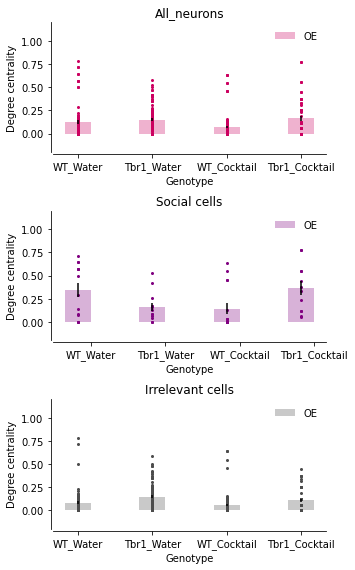

In [13]:
# Bar plot (related to Fig. 4E; data redrawn in Prism)

N = 4
ind = np.arange(N)    # the x locations for the groups
width = 0.35         # the width of the bars
plt.figure (figsize = (5,8))


# All_neurons
ax1 = plt.subplot(3,1,1)

Water_OE_means_DC = [WT_Water_OE_cells_mean_DC, Tbr1_Water_OE_cells_mean_DC,
                        WT_Cocktail_OE_cells_mean_DC, Tbr1_Cocktail_OE_cells_mean_DC]

Water_OE_sem_DC = [WT_Water_OE_cells_sem_DC, Tbr1_Water_OE_cells_sem_DC,
                      WT_Cocktail_OE_cells_sem_DC, Tbr1_Cocktail_OE_cells_sem_DC]

ax1.bar(ind, Water_OE_means_DC, width, yerr=Water_OE_sem_DC, label='OE', color="#cc0060", alpha=0.3)

frames1= [WT_Water_OE_cells["Degree_centrality"], Tbr1_Water_OE_cells["Degree_centrality"], 
          WT_Cocktail_OE_cells["Degree_centrality"], Tbr1_Cocktail_OE_cells["Degree_centrality"]]
results1 = pd.concat(frames1)

ax1.scatter(([0]*len(WT_Water_OE_cells["Degree_centrality"])+
             [1]*len(Tbr1_Water_OE_cells["Degree_centrality"])+
             [2]*len(WT_Cocktail_OE_cells["Degree_centrality"])+
             [3]*len(Tbr1_Cocktail_OE_cells["Degree_centrality"])), 
            (results1), 
            s=4, c= "#cc0060")

ax1.set_xticks([])
ax1.set(ylim=(-.2, 1.2))
plt.xticks(ind,['WT_Water','Tbr1_Water', 'WT_Cocktail','Tbr1_Cocktail'], rotation=0)

ax1.set_title("All_neurons")
plt.xlabel ("Genotype")
plt.ylabel ("Degree centrality")

ax1.legend(frameon=False)


# OE_neurons
ax2 = plt.subplot(3,1,2)

Water_OE_SC_means_DC = [WT_Water_OE_socialcells_mean_DC, Tbr1_Water_OE_socialcells_mean_DC,
                        WT_Cocktail_OE_socialcells_mean_DC, Tbr1_Cocktail_OE_socialcells_mean_DC]

Water_OE_SC_sem_DC = [WT_Water_OE_socialcells_sem_DC, Tbr1_Water_OE_socialcells_sem_DC,
                      WT_Cocktail_OE_socialcells_sem_DC, Tbr1_Cocktail_OE_socialcells_sem_DC]

ax2.bar(ind , Water_OE_SC_means_DC, width, yerr=Water_OE_SC_sem_DC, label='OE', color="purple", alpha=0.3)

frames2= [WT_Water_OE_socialcells["Degree_centrality"], Tbr1_Water_OE_socialcells["Degree_centrality"], 
          WT_Cocktail_OE_socialcells["Degree_centrality"], Tbr1_Cocktail_OE_socialcells["Degree_centrality"]]
results2 = pd.concat(frames2)

ax2.scatter(([0]*len(WT_Water_OE_socialcells["Degree_centrality"])+
             [1]*len(Tbr1_Water_OE_socialcells["Degree_centrality"])+
             [2]*len(WT_Cocktail_OE_socialcells["Degree_centrality"])+
             [3]*len(Tbr1_Cocktail_OE_socialcells["Degree_centrality"])), 
            (results2), 
            s=4, c="purple")

ax2.set_xticks([])
ax2.set(ylim=(-.2, 1.2))
plt.xticks(ind+width/2,['WT_Water','Tbr1_Water', 'WT_Cocktail','Tbr1_Cocktail'], rotation=0)

ax2.set_title("Social cells")
plt.xlabel ("Genotype")
plt.ylabel ("Degree centrality")

ax2.legend(frameon=False)


# Irrelevant_neurons
ax3 = plt.subplot(3,1,3)

Water_OE_SC_means_DC = [WT_Water_OE_othercells_mean_DC, Tbr1_Water_OE_othercells_mean_DC,
                        WT_Cocktail_OE_othercells_mean_DC, Tbr1_Cocktail_OE_othercells_mean_DC]

Water_OE_SC_sem_DC = [WT_Water_OE_othercells_sem_DC, Tbr1_Water_OE_othercells_sem_DC,
                      WT_Cocktail_OE_othercells_sem_DC, Tbr1_Cocktail_OE_othercells_sem_DC]

ax3.bar(ind , Water_OE_SC_means_DC, width, yerr=Water_OE_SC_sem_DC, label='OE', color="#4C4C4C", alpha=0.3)

frames3= [WT_Water_OE_othercells["Degree_centrality"], Tbr1_Water_OE_othercells["Degree_centrality"], 
          WT_Cocktail_OE_othercells["Degree_centrality"], Tbr1_Cocktail_OE_othercells["Degree_centrality"]]
results3 = pd.concat(frames3)

ax3.scatter(([0]*len(WT_Water_OE_othercells["Degree_centrality"])+
             [1]*len(Tbr1_Water_OE_othercells["Degree_centrality"])+
             [2]*len(WT_Cocktail_OE_othercells["Degree_centrality"])+
             [3]*len(Tbr1_Cocktail_OE_othercells["Degree_centrality"])), 
            (results3), 
            s=4, c="#4C4C4C")

ax3.set_xticks([])
ax3.set(ylim=(-.2, 1.2))
plt.xticks(ind,['WT_Water','Tbr1_Water', 'WT_Cocktail','Tbr1_Cocktail'], rotation=0)

ax3.set_title("Irrelevant cells")
plt.xlabel ("Genotype")
plt.ylabel ("Degree centrality")

ax3.legend(frameon=False)

plt.tight_layout()
sns.despine(offset=2)


# plt.savefig(savefig + "Degree_centrality.pdf", transparent= True, bbox_inches="tight")


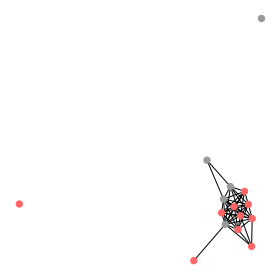

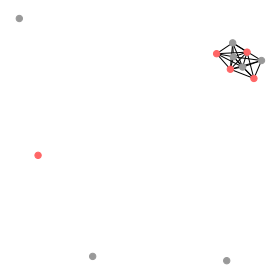

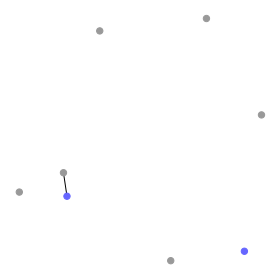

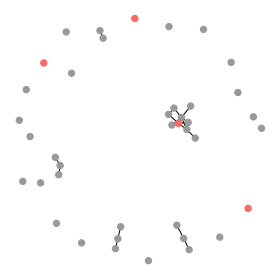

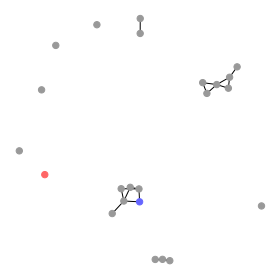

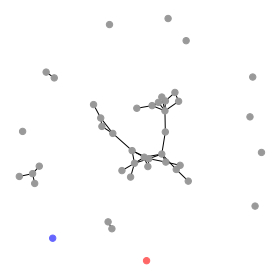

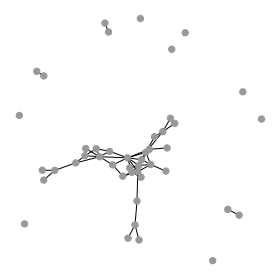

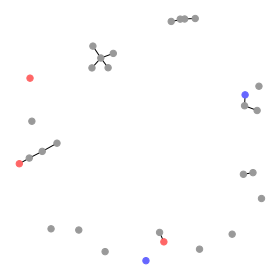

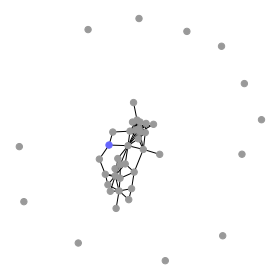

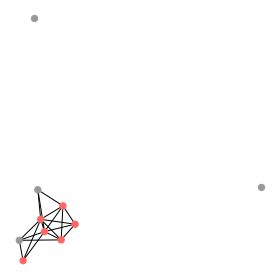

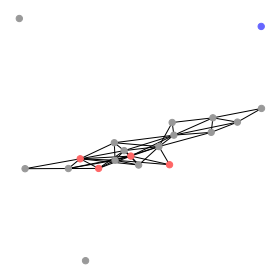

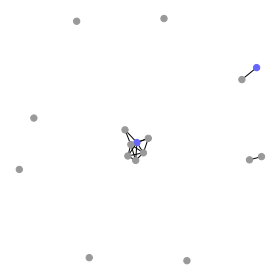

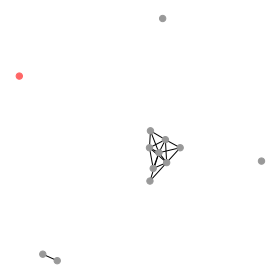

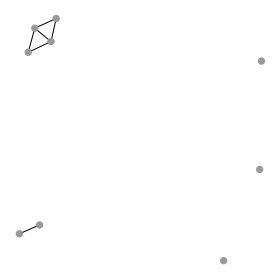

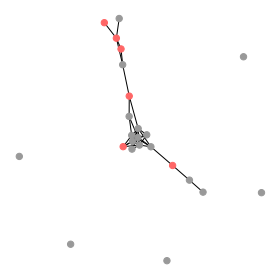

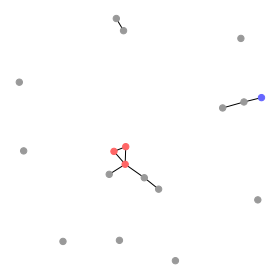

In [16]:
# Example of Networks (WT:NO.8, Tbr1:NO.20) (related to Fig. 4D and Supplementary Fig. 8)
# Genotype of each number
WT_Number = ["NO.1", "NO.2", "NO.8", "NO.15"]
Tbr1_Number = ["NO.3", "NO.13", "NO.16", "NO.20"]

# Treatment and behavior
drinks = ["Water", "Cocktail"]
behaviors = ["OE"]

for nm in WT_Number:
    
    # Read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt")
    # Read Multi-session registration file
    MSR = pd.read_csv("./Calcium_imaging_data/Multi-session_registration_"+ nm +".csv", index_col=0, header=0)
    
    for dk in drinks:
        for bh in behaviors:
        
            savecsv1 = savecsv + "WT/" + nm + "/" + dk + "/" + bh + "/"
            savefig1 = savefig + "WT/" + nm + "/" + dk + "/" + bh + "/"
            
            Networkx_fig_OE (nm, dk, bh, savecsv1, savefig1)

for nm in Tbr1_Number:
    
    # Read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt")
    # Read Multi-session registration file
    MSR = pd.read_csv("./Calcium_imaging_data/Multi-session_registration_"+ nm +".csv", index_col=0, header=0)
    
    for dk in drinks:
        for bh in behaviors:
        
            savecsv1 = savecsv + "Tbr1/" + nm + "/" + dk + "/" + bh + "/"
            savefig1 = savefig + "Tbr1/" + nm + "/" + dk + "/" + bh + "/"
            
            Networkx_fig_OE (nm, dk, bh, savecsv1, savefig1)

# Analysis of sociality_linked_neurons

In [17]:
# Genotype of each number
WT_Number = ["NO.1", "NO.2", "NO.8", "NO.15"]
Tbr1_Number = ["NO.3", "NO.13", "NO.16", "NO.20"]

# Treatment and behavior
drinks = ["Water", "Cocktail"]
behaviors = ["RSI"]

In [18]:
# Create files
if not os.path.exists("Results"): os.mkdir("Results")
if not os.path.exists("Results/Networkx"): os.mkdir("Results/Networkx")
if not os.path.exists("Results/Networkx/output_csv"): os.mkdir("Results/Networkx/output_csv")
if not os.path.exists("Results/Networkx/output_csv/sociality_linked_neurons"): os.mkdir("Results/Networkx/output_csv/sociality_linked_neurons")

if not os.path.exists("Results/Networkx/figure"): os.mkdir("Results/Networkx/figure")
if not os.path.exists("Results/Networkx/figure/sociality_linked_neurons"): os.mkdir("Results/Networkx/figure/sociality_linked_neurons")
    
savecsv = "Results/Networkx/output_csv/sociality_linked_neurons/" 
savefig = "Results/Networkx/figure/sociality_linked_neurons/"

In [20]:
# WT data analysis
if not os.path.exists(savecsv + "WT"): os.mkdir(savecsv + "WT")
if not os.path.exists(savefig + "WT"): os.mkdir(savefig + "WT")
    
WT_Centrality = pd.DataFrame([])

for nm in WT_Number:
    
    if not os.path.exists(savecsv + "WT/" + nm): os.mkdir(savecsv + "WT/" + nm)
    if not os.path.exists(savefig + "WT/" + nm): os.mkdir(savefig + "WT/" + nm)
    
    # Read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt")
    
    # Read Multi-session registration file
    MSR = pd.read_csv("./Calcium_imaging_data/Multi-session_registration_"+ nm +".csv", index_col=0, header=0)
    
    for dk in drinks:
        
        if not os.path.exists(savecsv + "WT/" + nm + "/" + dk): os.mkdir(savecsv + "WT/" + nm + "/" + dk)
        if not os.path.exists(savefig + "WT/" + nm + "/" + dk): os.mkdir(savefig + "WT/" + nm + "/" + dk)
            
        for bh in behaviors:
            
            if not os.path.exists(savecsv + "WT/" + nm + "/" + dk + "/" + bh): os.mkdir(savecsv + "WT/" + nm + "/" + dk + "/" + bh)
            if not os.path.exists(savefig + "WT/" + nm + "/" + dk + "/" + bh): os.mkdir(savefig + "WT/" + nm + "/" + dk + "/" + bh)
        
            savecsv1 = savecsv + "WT/" + nm + "/" + dk + "/" + bh + "/"
            savefig1 = savefig + "WT/" + nm + "/" + dk + "/" + bh + "/"

            
            Cosine_similarity(nm, dk, bh, savecsv1)
            
            Networkx_function_RSI(nm, dk, bh, savecsv1, savefig1)


            # Read Centrality file
            Centrality = pd.read_csv(savecsv1+ "Centrality_all.csv", index_col=0, header=0)
            Centrality["Genotype"] = "WT"
            Centrality["Drink"] = dk
            Centrality["Behavior"] = bh
            Centrality["Number"] = nm
            
            WT_Centrality = WT_Centrality.append(Centrality, ignore_index=True)
                        
WT_Centrality


,Degree_centrality,Eigenvector_centrality,Cell_type,Genotype,Drink,Behavior,Number
0,0.058824,3.738542e-02,other,WT,Water,RSI,NO.1
1,0.470588,2.884067e-01,other,WT,Water,RSI,NO.1
2,0.529412,3.099027e-01,other,WT,Water,RSI,NO.1
3,0.176471,1.098843e-01,other,WT,Water,RSI,NO.1
4,0.000000,4.148968e-10,other,WT,Water,RSI,NO.1
...,...,...,...,...,...,...,...
265,0.046512,2.084614e-07,other,WT,Cocktail,RSI,NO.15
266,0.023256,1.203554e-07,inhibition,WT,Cocktail,RSI,NO.15
267,0.000000,4.095572e-13,other,WT,Cocktail,RSI,NO.15
268,0.000000,4.095572e-13,inhibition,WT,Cocktail,RSI,NO.15


In [21]:
# Tbr1 data analysis
if not os.path.exists(savecsv + "Tbr1"): os.mkdir(savecsv + "Tbr1")
if not os.path.exists(savefig + "Tbr1"): os.mkdir(savefig + "Tbr1")
    
Tbr1_Centrality = pd.DataFrame([])

for nm in Tbr1_Number:
    
    if not os.path.exists(savecsv + "Tbr1/" + nm): os.mkdir(savecsv + "Tbr1/" + nm)
    if not os.path.exists(savefig + "Tbr1/" + nm): os.mkdir(savefig + "Tbr1/" + nm)
    
    # Read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt")
    
    # Read Multi-session registration file
    MSR = pd.read_csv("./Calcium_imaging_data/Multi-session_registration_"+ nm +".csv", index_col=0, header=0)
    
    for dk in drinks:
        
        if not os.path.exists(savecsv + "Tbr1/" + nm + "/" + dk): os.mkdir(savecsv + "Tbr1/" + nm + "/" + dk)
        if not os.path.exists(savefig + "Tbr1/" + nm + "/" + dk): os.mkdir(savefig + "Tbr1/" + nm + "/" + dk)
            
        for bh in behaviors:
            
            if not os.path.exists(savecsv + "Tbr1/" + nm + "/" + dk + "/" + bh): os.mkdir(savecsv + "Tbr1/" + nm + "/" + dk + "/" + bh)
            if not os.path.exists(savefig + "Tbr1/" + nm + "/" + dk + "/" + bh): os.mkdir(savefig + "Tbr1/" + nm + "/" + dk + "/" + bh)
        
            savecsv1 = savecsv + "Tbr1/" + nm + "/" + dk + "/" + bh + "/"
            savefig1 = savefig + "Tbr1/" + nm + "/" + dk + "/" + bh + "/"

            
            Cosine_similarity(nm, dk, bh, savecsv1)
            
            Networkx_function_RSI(nm, dk, bh, savecsv1, savefig1)


            #read Centrality file
            Centrality = pd.read_csv(savecsv1+ "Centrality_all.csv", index_col=0, header=0)
            Centrality["Genotype"] = "Tbr1"
            Centrality["Drink"] = dk
            Centrality["Behavior"] = bh
            Centrality["Number"] = nm
            
            Tbr1_Centrality = Tbr1_Centrality.append(Centrality, ignore_index=True)
        
Tbr1_Centrality


,Degree_centrality,Eigenvector_centrality,Cell_type,Genotype,Drink,Behavior,Number
0,0.000000,9.763677e-23,other,Tbr1,Water,RSI,NO.3
1,0.081081,6.219597e-02,other,Tbr1,Water,RSI,NO.3
2,0.054054,6.432056e-04,other,Tbr1,Water,RSI,NO.3
3,0.027027,4.373613e-03,activation,Tbr1,Water,RSI,NO.3
4,0.027027,4.373613e-03,other,Tbr1,Water,RSI,NO.3
...,...,...,...,...,...,...,...
158,0.000000,2.206341e-11,activation,Tbr1,Cocktail,RSI,NO.20
159,0.409091,2.202517e-01,activation,Tbr1,Cocktail,RSI,NO.20
160,0.590909,3.537703e-01,other,Tbr1,Cocktail,RSI,NO.20
161,0.045455,2.405646e-02,other,Tbr1,Cocktail,RSI,NO.20


In [22]:
# Separate different group
WT_Water_RSI_cells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                   (WT_Centrality["Drink"]=="Water") & 
                                   (WT_Centrality["Behavior"]=="RSI")]

WT_Cocktail_RSI_cells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                      (WT_Centrality["Drink"]=="Cocktail") & 
                                      (WT_Centrality["Behavior"]=="RSI")]

Tbr1_Water_RSI_cells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                       (Tbr1_Centrality["Drink"]=="Water") & 
                                       (Tbr1_Centrality["Behavior"]=="RSI")]

Tbr1_Cocktail_RSI_cells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                          (Tbr1_Centrality["Drink"]=="Cocktail") & 
                                          (Tbr1_Centrality["Behavior"]=="RSI")]

#calculate mean (Degree_centrality)
WT_Water_RSI_cells_mean_DC = WT_Water_RSI_cells["Degree_centrality"].mean(axis=0)
WT_Water_RSI_cells_mean_DC = WT_Water_RSI_cells["Degree_centrality"].mean(axis=0)
WT_Cocktail_RSI_cells_mean_DC = WT_Cocktail_RSI_cells["Degree_centrality"].mean(axis=0)
WT_Cocktail_RSI_cells_mean_DC = WT_Cocktail_RSI_cells["Degree_centrality"].mean(axis=0)

Tbr1_Water_RSI_cells_mean_DC = Tbr1_Water_RSI_cells["Degree_centrality"].mean(axis=0)
Tbr1_Water_RSI_cells_mean_DC = Tbr1_Water_RSI_cells["Degree_centrality"].mean(axis=0)
Tbr1_Cocktail_RSI_cells_mean_DC = Tbr1_Cocktail_RSI_cells["Degree_centrality"].mean(axis=0)
Tbr1_Cocktail_RSI_cells_mean_DC = Tbr1_Cocktail_RSI_cells["Degree_centrality"].mean(axis=0)

#calculate sem (Degree_centrality)
WT_Water_RSI_cells_sem_DC = WT_Water_RSI_cells["Degree_centrality"].sem(axis=0)
WT_Water_RSI_cells_sem_DC = WT_Water_RSI_cells["Degree_centrality"].sem(axis=0)
WT_Cocktail_RSI_cells_sem_DC = WT_Cocktail_RSI_cells["Degree_centrality"].sem(axis=0)
WT_Cocktail_RSI_cells_sem_DC = WT_Cocktail_RSI_cells["Degree_centrality"].sem(axis=0)

Tbr1_Water_RSI_cells_sem_DC = Tbr1_Water_RSI_cells["Degree_centrality"].sem(axis=0)
Tbr1_Water_RSI_cells_sem_DC = Tbr1_Water_RSI_cells["Degree_centrality"].sem(axis=0)
Tbr1_Cocktail_RSI_cells_sem_DC = Tbr1_Cocktail_RSI_cells["Degree_centrality"].sem(axis=0)
Tbr1_Cocktail_RSI_cells_sem_DC = Tbr1_Cocktail_RSI_cells["Degree_centrality"].sem(axis=0)

# Save csv
All_centrality = WT_Centrality.append(Tbr1_Centrality, ignore_index=True)
pd.DataFrame(All_centrality).to_csv(savecsv + "Centrality_summary.csv")

In [23]:
# Separate different group (Social and irrelevant neurons)
WT_Water_RSI_socialcells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                         (WT_Centrality["Drink"]=="Water") & 
                                         (WT_Centrality["Behavior"]=="RSI") & 
                                         (WT_Centrality["Cell_type"].isin(["activation", "inhibition"]))]


WT_Water_RSI_othercells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                        (WT_Centrality["Drink"]=="Water") & 
                                        (WT_Centrality["Behavior"]=="RSI") & 
                                        (WT_Centrality["Cell_type"]=="other")]

WT_Cocktail_RSI_socialcells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                         (WT_Centrality["Drink"]=="Cocktail") & 
                                         (WT_Centrality["Behavior"]=="RSI") & 
                                         (WT_Centrality["Cell_type"].isin(["activation", "inhibition"]))]


WT_Cocktail_RSI_othercells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                        (WT_Centrality["Drink"]=="Cocktail") & 
                                        (WT_Centrality["Behavior"]=="RSI") & 
                                        (WT_Centrality["Cell_type"]=="other")]



# Separate different group (Tbr1)
Tbr1_Water_RSI_socialcells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                             (Tbr1_Centrality["Drink"]=="Water") & 
                                             (Tbr1_Centrality["Behavior"]=="RSI") & 
                                             (Tbr1_Centrality["Cell_type"].isin(["activation", "inhibition"]))]

Tbr1_Water_RSI_othercells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                            (Tbr1_Centrality["Drink"]=="Water") & 
                                            (Tbr1_Centrality["Behavior"]=="RSI") & 
                                            (Tbr1_Centrality["Cell_type"]=="other")]

Tbr1_Cocktail_RSI_socialcells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                             (Tbr1_Centrality["Drink"]=="Cocktail") & 
                                             (Tbr1_Centrality["Behavior"]=="RSI") & 
                                             (Tbr1_Centrality["Cell_type"].isin(["activation", "inhibition"]))]

Tbr1_Cocktail_RSI_othercells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                            (Tbr1_Centrality["Drink"]=="Cocktail") & 
                                            (Tbr1_Centrality["Behavior"]=="RSI") & 
                                            (Tbr1_Centrality["Cell_type"]=="other")]




# Calculate mean (Degree_centrality)
WT_Water_RSI_socialcells_mean_DC = WT_Water_RSI_socialcells["Degree_centrality"].mean(axis=0)
WT_Water_RSI_othercells_mean_DC = WT_Water_RSI_othercells["Degree_centrality"].mean(axis=0)
WT_Cocktail_RSI_socialcells_mean_DC = WT_Cocktail_RSI_socialcells["Degree_centrality"].mean(axis=0)
WT_Cocktail_RSI_othercells_mean_DC = WT_Cocktail_RSI_othercells["Degree_centrality"].mean(axis=0)

Tbr1_Water_RSI_socialcells_mean_DC = Tbr1_Water_RSI_socialcells["Degree_centrality"].mean(axis=0)
Tbr1_Water_RSI_othercells_mean_DC = Tbr1_Water_RSI_othercells["Degree_centrality"].mean(axis=0)
Tbr1_Cocktail_RSI_socialcells_mean_DC = Tbr1_Cocktail_RSI_socialcells["Degree_centrality"].mean(axis=0)
Tbr1_Cocktail_RSI_othercells_mean_DC = Tbr1_Cocktail_RSI_othercells["Degree_centrality"].mean(axis=0)

# Calculate sem (Degree_centrality)
WT_Water_RSI_socialcells_sem_DC = WT_Water_RSI_socialcells["Degree_centrality"].sem(axis=0)
WT_Water_RSI_othercells_sem_DC = WT_Water_RSI_othercells["Degree_centrality"].sem(axis=0)
WT_Cocktail_RSI_socialcells_sem_DC = WT_Cocktail_RSI_socialcells["Degree_centrality"].sem(axis=0)
WT_Cocktail_RSI_othercells_sem_DC = WT_Cocktail_RSI_othercells["Degree_centrality"].sem(axis=0)


Tbr1_Water_RSI_socialcells_sem_DC = Tbr1_Water_RSI_socialcells["Degree_centrality"].sem(axis=0)
Tbr1_Water_RSI_othercells_sem_DC = Tbr1_Water_RSI_othercells["Degree_centrality"].sem(axis=0)
Tbr1_Cocktail_RSI_socialcells_sem_DC = Tbr1_Cocktail_RSI_socialcells["Degree_centrality"].sem(axis=0)
Tbr1_Cocktail_RSI_othercells_sem_DC = Tbr1_Cocktail_RSI_othercells["Degree_centrality"].sem(axis=0)


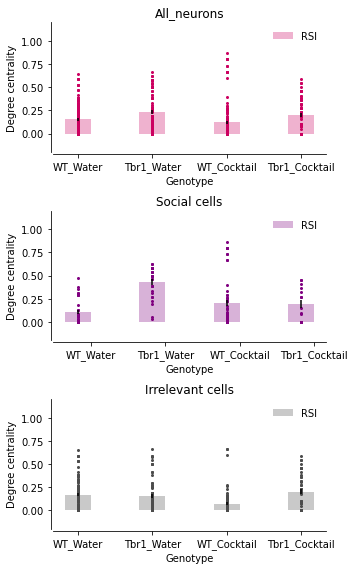

In [24]:
# Bar plot (related to Fig. 4C; data redrawn in Prism)

N = 4
ind = np.arange(N)    # the x locations for the groups
# width = 0.35         # the width of the bars
plt.figure (figsize = (5,8))


# All_neurons
ax1 = plt.subplot(3,1,1)

Water_RSI_means_DC = [WT_Water_RSI_cells_mean_DC, Tbr1_Water_RSI_cells_mean_DC,
                        WT_Cocktail_RSI_cells_mean_DC, Tbr1_Cocktail_RSI_cells_mean_DC]

Water_RSI_sem_DC = [WT_Water_RSI_cells_sem_DC, Tbr1_Water_RSI_cells_sem_DC,
                      WT_Cocktail_RSI_cells_sem_DC, Tbr1_Cocktail_RSI_cells_sem_DC]

ax1.bar(ind, Water_RSI_means_DC, width, yerr=Water_RSI_sem_DC, label='RSI', color="#cc0060", alpha=0.3)

frames1= [WT_Water_RSI_cells["Degree_centrality"], Tbr1_Water_RSI_cells["Degree_centrality"], 
          WT_Cocktail_RSI_cells["Degree_centrality"], Tbr1_Cocktail_RSI_cells["Degree_centrality"]]
results1 = pd.concat(frames1)

ax1.scatter(([0]*len(WT_Water_RSI_cells["Degree_centrality"])+
             [1]*len(Tbr1_Water_RSI_cells["Degree_centrality"])+
             [2]*len(WT_Cocktail_RSI_cells["Degree_centrality"])+
             [3]*len(Tbr1_Cocktail_RSI_cells["Degree_centrality"])), 
            (results1), 
            s=4, c= "#cc0060")

ax1.set_xticks([])
ax1.set(ylim=(-.2, 1.2))
plt.xticks(ind,['WT_Water','Tbr1_Water', 'WT_Cocktail','Tbr1_Cocktail'], rotation=0)

ax1.set_title("All_neurons")
plt.xlabel ("Genotype")
plt.ylabel ("Degree centrality")

ax1.legend(frameon=False)


# Social_neurons
ax2 = plt.subplot(3,1,2)

Water_RSI_SC_means_DC = [WT_Water_RSI_socialcells_mean_DC, Tbr1_Water_RSI_socialcells_mean_DC,
                        WT_Cocktail_RSI_socialcells_mean_DC, Tbr1_Cocktail_RSI_socialcells_mean_DC]

Water_RSI_SC_sem_DC = [WT_Water_RSI_socialcells_sem_DC, Tbr1_Water_RSI_socialcells_sem_DC,
                      WT_Cocktail_RSI_socialcells_sem_DC, Tbr1_Cocktail_RSI_socialcells_sem_DC]

ax2.bar(ind , Water_RSI_SC_means_DC, width, yerr=Water_RSI_SC_sem_DC, label='RSI', color="purple", alpha=0.3)

frames2= [WT_Water_RSI_socialcells["Degree_centrality"], Tbr1_Water_RSI_socialcells["Degree_centrality"], 
          WT_Cocktail_RSI_socialcells["Degree_centrality"], Tbr1_Cocktail_RSI_socialcells["Degree_centrality"]]
results2 = pd.concat(frames2)

ax2.scatter(([0]*len(WT_Water_RSI_socialcells["Degree_centrality"])+
             [1]*len(Tbr1_Water_RSI_socialcells["Degree_centrality"])+
             [2]*len(WT_Cocktail_RSI_socialcells["Degree_centrality"])+
             [3]*len(Tbr1_Cocktail_RSI_socialcells["Degree_centrality"])), 
            (results2), 
            s=4, c="purple")

ax2.set_xticks([])
ax2.set(ylim=(-.2, 1.2))
plt.xticks(ind+width/2,['WT_Water','Tbr1_Water', 'WT_Cocktail','Tbr1_Cocktail'], rotation=0)

ax2.set_title("Social cells")
plt.xlabel ("Genotype")
plt.ylabel ("Degree centrality")

ax2.legend(frameon=False)


# Irrelevant_neurons
ax3 = plt.subplot(3,1,3)

Water_RSI_SC_means_DC = [WT_Water_RSI_othercells_mean_DC, Tbr1_Water_RSI_othercells_mean_DC,
                        WT_Cocktail_RSI_othercells_mean_DC, Tbr1_Cocktail_RSI_othercells_mean_DC]

Water_RSI_SC_sem_DC = [WT_Water_RSI_othercells_sem_DC, Tbr1_Water_RSI_othercells_sem_DC,
                      WT_Cocktail_RSI_othercells_sem_DC, Tbr1_Cocktail_RSI_othercells_sem_DC]

ax3.bar(ind , Water_RSI_SC_means_DC, width, yerr=Water_RSI_SC_sem_DC, label='RSI', color="#4C4C4C", alpha=0.3)

frames3= [WT_Water_RSI_othercells["Degree_centrality"], Tbr1_Water_RSI_othercells["Degree_centrality"], 
          WT_Cocktail_RSI_othercells["Degree_centrality"], Tbr1_Cocktail_RSI_othercells["Degree_centrality"]]
results3 = pd.concat(frames3)

ax3.scatter(([0]*len(WT_Water_RSI_othercells["Degree_centrality"])+
             [1]*len(Tbr1_Water_RSI_othercells["Degree_centrality"])+
             [2]*len(WT_Cocktail_RSI_othercells["Degree_centrality"])+
             [3]*len(Tbr1_Cocktail_RSI_othercells["Degree_centrality"])), 
            (results3), 
            s=4, c="#4C4C4C")

ax3.set_xticks([])
ax3.set(ylim=(-.2, 1.2))
plt.xticks(ind,['WT_Water','Tbr1_Water', 'WT_Cocktail','Tbr1_Cocktail'], rotation=0)

ax3.set_title("Irrelevant cells")
plt.xlabel ("Genotype")
plt.ylabel ("Degree centrality")

ax3.legend(frameon=False)

plt.tight_layout()
sns.despine(offset=2)


# plt.savefig(savefig + "Degree_centrality.pdf", transparent= True, bbox_inches="tight")


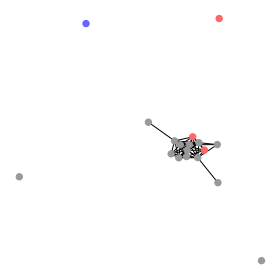

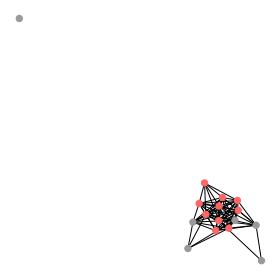

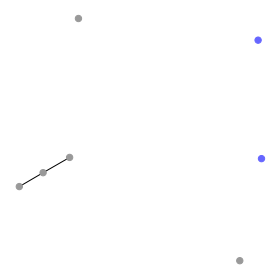

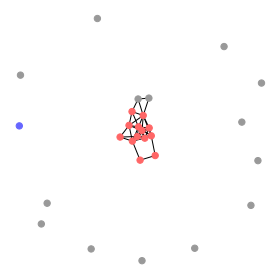

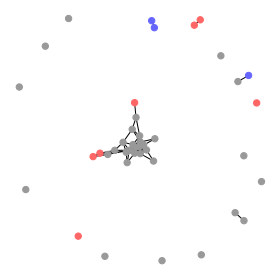

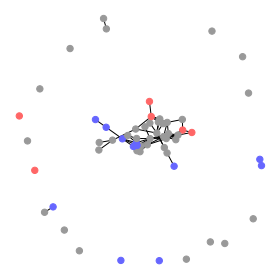

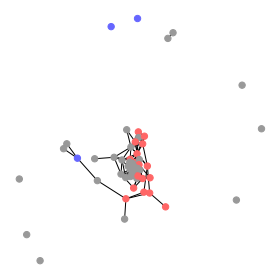

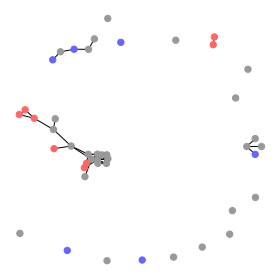

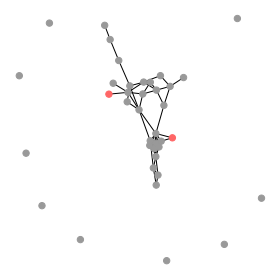

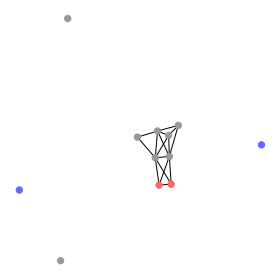

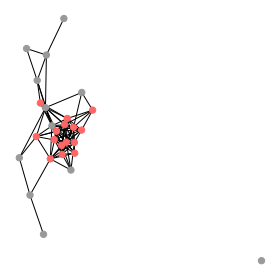

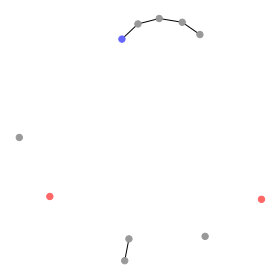

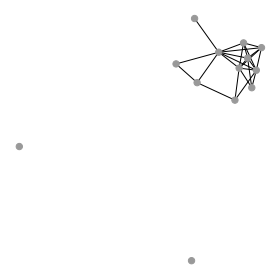

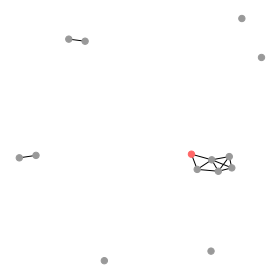

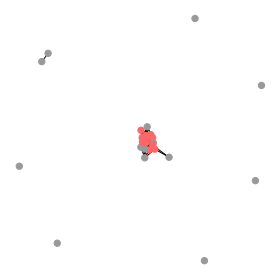

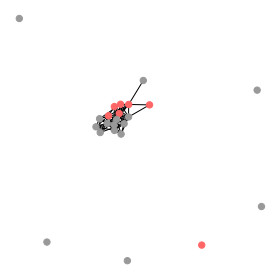

In [26]:
# Example of Networks (WT:NO.8, Tbr1:NO.20) (related to Fig. 4B and Supplementary Fig. 7)
# Genotype of each number
WT_Number = ["NO.1", "NO.2", "NO.8", "NO.15"]
Tbr1_Number = ["NO.3", "NO.13", "NO.16", "NO.20"]

# Treatment and behavior
drinks = ["Water", "Cocktail"]
behaviors = ["RSI"]

for nm in WT_Number:
    
    # Read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt")
    # Read Multi-session registration file
    MSR = pd.read_csv("./Calcium_imaging_data/Multi-session_registration_"+ nm +".csv", index_col=0, header=0)
    
    for dk in drinks:
        for bh in behaviors:
        
            savecsv1 = savecsv + "WT/" + nm + "/" + dk + "/" + bh + "/"
            savefig1 = savefig + "WT/" + nm + "/" + dk + "/" + bh + "/"
            
            Networkx_fig_RSI(nm, dk, bh, savecsv1, savefig1)

for nm in Tbr1_Number:
    
    # Read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt")
    # Read Multi-session registration file
    MSR = pd.read_csv("./Calcium_imaging_data/Multi-session_registration_"+ nm +".csv", index_col=0, header=0)
    
    for dk in drinks:
        for bh in behaviors:
        
            savecsv1 = savecsv + "Tbr1/" + nm + "/" + dk + "/" + bh + "/"
            savefig1 = savefig + "Tbr1/" + nm + "/" + dk + "/" + bh + "/"
            
            Networkx_fig_RSI(nm, dk, bh, savecsv1, savefig1)